In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from astropy.cosmology import LambdaCDM
import astropy.units as u
from astropy.io import fits
from scipy import interpolate

from simbanator.sed.makesed import MakeSED
from simbanator.io.simba import Simulation

cosmo = LambdaCDM(H0 = 68, Om0= 0.3, Ode0= 0.7, Ob0=0.048)
plt.rcParams.update({'font.size': 28})

sim = Simulation('cis100')

[Simulation] Loading snap→z mapping from: /mnt/home/glorenzon/analize_simba_cgm/simbanator/data/snap_z_maps/zsnap_map_caesar_box100.txt


In [2]:
# initialize SED making class
hydro_dir_base = os.path.join(os.getcwd(), 'output', sim.name, 'filtered')
preselect = '/mnt/home/glorenzon/output/quenching_times/legacy_poststarbursts_snpa_id.txt'
selection_file = 'selection_simba100_poststarburst.hdf5'
makesed = MakeSED(sim, nnodes=1, model_run_name='PSBG_dust_on', hydro_dir_base=hydro_dir_base, selection_file=selection_file, preselect=preselect)
print('Using hydro_dir_base:', hydro_dir_base)

Using hydro_dir_base: /mnt/home/glorenzon/analize_simba_cgm/output/cis100/filtered


In [4]:
with fits.open('/mnt/home/glorenzon/analize_simba_cgm/output/cis100/quenching_times/forward_modeled_unique_sample.fits') as f:
    snaps = f[1].data['SNAPSHOT']
    ids   = f[1].data['GROUPID_SNAPSHOT']

makesed.selection_gals(snaps=[101], galaxyID=[1987]) # create the hdf5 selection
makesed.create_master('cluster', 'plist', radius=None, partition='INTEL_HASWELL', prefix='m100n1024') # create the parameters masters

yt : [INFO     ] 2026-03-26 18:46:26,160 Opening /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_101.hdf5
yt : [INFO     ] 2026-03-26 18:46:26,527 Found 535268 halos
yt : [INFO     ] 2026-03-26 18:46:26,738 Found 38320 galaxies


Written data for snap101
writing slurm submission master script file
/mnt/home/glorenzon/analize_simba_cgm/output/cis100/sed/powderday_sed_out/PSBG_dust_on/snap_092/master.snap92.job
writing slurm submission master script file
/mnt/home/glorenzon/analize_simba_cgm/output/cis100/sed/powderday_sed_out/PSBG_dust_on/snap_094/master.snap94.job
writing slurm submission master script file
/mnt/home/glorenzon/analize_simba_cgm/output/cis100/sed/powderday_sed_out/PSBG_dust_on/snap_095/master.snap95.job
writing slurm submission master script file
/mnt/home/glorenzon/analize_simba_cgm/output/cis100/sed/powderday_sed_out/PSBG_dust_on/snap_096/master.snap96.job
writing slurm submission master script file
/mnt/home/glorenzon/analize_simba_cgm/output/cis100/sed/powderday_sed_out/PSBG_dust_on/snap_097/master.snap97.job
writing slurm submission master script file
/mnt/home/glorenzon/analize_simba_cgm/output/cis100/sed/powderday_sed_out/PSBG_dust_on/snap_098/master.snap98.job
writing slurm submission ma

In [3]:
makesed.extract_flux(102, 1458, 'JWST', 'NIRCam',
                     filters=None, wave_unit='micron', findx=0)

'/mnt/home/glorenzon/analize_simba_cgm/output/cis100/sed/sed_fluxes/snap_102/gal_001458_fluxes.fits'

In [2]:
with fits.open('/mnt/home/glorenzon/output/quenching_times/legacy_zsp_sampled_snapshots_with_ids.fits') as f:
    snaps = f[1].data['SNAPSHOT']
    ids   = f[1].data['GROUPID_SNAPSHOT']

fig, ax = plt.subplots()
for i in range(len(ids)):
    try: 
        nu, flux = makesed.plotsed(snaps[i], ids[i], show=False, retval=True)
    except:
        continue
    ax.loglog(nu, flux[0])
fig.savefig('test_.png')

KeyError: "Key 'SNAPSHOT' does not exist."

In [6]:
from svo_filters import svo
svo.filters()

['NIRISS.GR700XD.1',
 'WFPC2.F656N',
 'NSFCam.Mp',
 'NIRCam.F200W',
 'NIRCam.F323N',
 'NIRCam.F356W',
 'NIRISS.F277W',
 'Gaia.rp',
 'NIRCam.F322W2',
 'NIRCam.F430M',
 'MIRI.F2100W',
 'ACS_HRC.F555W',
 'FourStar.J3',
 'NIRISS.F444W',
 'IRAC.I4',
 'NSFCam.H',
 'NIRCam.F360M',
 'FourStar.J',
 'MIRI.F1800W',
 'NSFCam.K',
 'WFPC2.F814W',
 'WISE.W1',
 'NIRCam.F115W',
 'PS1.r',
 'PS1.i',
 'FourStar.J2',
 'WFC3_UVIS2.F814W',
 'Gaia.G',
 'SDSS.i',
 'MIRI.F770W',
 'NSFCam.Lp',
 'NIRCam.F182M',
 'NIRISS.F480M',
 'WFC3_UVIS2.F850LP',
 'HAWK_I.Ks',
 'NIRCam.F250M',
 'NIRCam.F140M',
 'MIRI.F1000W',
 'STIS.G430L',
 'WFC3_IR.F125W',
 'Kepler.K',
 'MIRI.F1500W',
 'PS1.y',
 'NIRISS.F150W',
 'WFC3_IR.G141',
 'NIRCam.F150W',
 'NIRCam.F470N',
 'Cousins.I',
 'Johnson.V',
 'GALEX.FUV',
 'Cousins.R',
 'NIRCam.F277W',
 'HAWK_I.H',
 'NIRISS.F356W',
 'NSFCam.J',
 'FourStar.J1',
 'NIRISS.F115W',
 'GALEX.NUV',
 'MIRI.F560W',
 'NIRCam.F300M',
 'WFPC2.F439W',
 'NIRCam.F212N',
 'Wircam.Y',
 'SDSS.u',
 'NIRCam.F070W',

In [9]:
filter_list = ['NIRCam.F200W', 'NIRCam.F356W']
nu, flux = makesed.plotsed(102, 1458, show=False, retval=True)
print(nu, flux)
def extract_with_svo(spec, filter_list):
    from svo_filters import svo
    convolved = {}
    for filter_n in filter_list:
        band = svo.Filter(filter_n)
        filtered = band.apply(spec, plot=True)
        convolved[filter_n] = filtered
    return convolved
from astropy import units as u
from astropy import constants as const

# frequency → wavelength
wav = nu.to(u.AA, equivalencies=u.spectral())

# mJy → Fν in cgs
fnu = flux.to(u.erg / (u.s * u.cm**2 * u.Hz))

# Fν → Fλ
flam = fnu * const.c.to(u.AA / u.s) / wav**2

spec = [wav, flam]
conv = extract_with_svo(spec, filter_list)

[1.44339129e+11 1.45138984e+11 1.45943272e+11 ... 1.41965913e+17
 1.42752617e+17 1.43543681e+17] Hz [[0.07593303 0.07724245 0.07857899 ... 0.         0.         0.        ]] mJy


{'NIRCam.F200W': (<Quantity [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
             nan, nan, nan, nan, nan, nan, nan, 

In [11]:
H_band = svo.Filter('NIRCam.F200W')
H_band.plot()
wave = H_band['WAVELENGTH']   # usually in Angstrom or nm (check metadata)
trans = H_band['TRANSMISSION']


TypeError: 'Filter' object is not subscriptable

In [5]:
makesed.plotsed(102, 1458, show=False)

In [ ]:
makesed

In [ ]:
from simbanator.utils.svo_filters import download_svo_filter
filt_out_dir = '/mnt/home/lorenzong/analize_simba_cgm/output/svo_filters'
download_svo_filter('', out_dir, overwrite=False)


In [13]:
H_band.__dir__()

['monotonic',
 'raw',
 'FilterProfileService',
 'filterID',
 'WavelengthUCD',
 'PhotSystem',
 'DetectorType',
 'Instrument',
 'Facility',
 'ProfileReference',
 'Comments',
 'PhotCalID',
 'MagSys',
 'ZeroPointType',
 'hm_x1',
 'hm_x2',
 'path',
 'pixels_per_bin',
 'n_bins',
 '_wave_units',
 '_wave',
 '_throughput',
 'wave_min',
 'wave_max',
 'wave_eff',
 'wave_center',
 'wave_mean',
 'wave_peak',
 'thru_peak',
 'wave_phot',
 'wave_pivot',
 'width_eff',
 'fwhm',
 'zp',
 '_flux_units',
 'refs',
 'CalibrationReference',
 'name',
 'ext_vector',
 'systematics',
 '__module__',
 '__doc__',
 '__init__',
 'apply',
 'bin',
 'flux_units',
 'info',
 'load_TopHat',
 'load_txt',
 'load_raw',
 'load_web',
 'load_xml',
 'overlap',
 'plot',
 'rsr',
 'throughput',
 'wave',
 'wave_units',
 '__repr__',
 '__dict__',
 '__weakref__',
 '__hash__',
 '__str__',
 '__getattribute__',
 '__setattr__',
 '__delattr__',
 '__lt__',
 '__le__',
 '__eq__',
 '__ne__',
 '__gt__',
 '__ge__',
 '__new__',
 '__reduce_ex__',
 '__

In [14]:
H_band.wave

<Quantity [[1.6904, 1.6914, 1.6924, 1.6934, 1.6944, 1.6954, 1.6964,
            1.6974, 1.6984, 1.6994, 1.7004, 1.7014, 1.7024, 1.7034,
            1.7044, 1.7054, 1.7064, 1.7074, 1.7084, 1.7094, 1.7104,
            1.7114, 1.7124, 1.7134, 1.7144, 1.7154, 1.7164, 1.7174,
            1.7184, 1.7194, 1.7204, 1.7214, 1.7224, 1.7234, 1.7244,
            1.7254, 1.7264, 1.7274, 1.7284, 1.7294, 1.7304, 1.7314,
            1.7324, 1.7334, 1.7344, 1.7354, 1.7364, 1.7374, 1.7384,
            1.7394, 1.7404, 1.7414, 1.7424, 1.7434, 1.7444, 1.7454,
            1.7464, 1.7474, 1.7484, 1.7494, 1.7504, 1.7514, 1.7524,
            1.7534, 1.7544, 1.7554, 1.7564, 1.7574, 1.7584, 1.7594,
            1.7604, 1.7614, 1.7624, 1.7634, 1.7644, 1.7654, 1.7664,
            1.7674, 1.7684, 1.7694, 1.7704, 1.7714, 1.7724, 1.7734,
            1.7744, 1.7754, 1.7764, 1.7774, 1.7784, 1.7794, 1.7804,
            1.7814, 1.7824, 1.7834, 1.7844, 1.7854, 1.7864, 1.7874,
            1.7884, 1.7894, 1.7904, 1.7914, 1.79

In [19]:
plt.figure()
plt.plot(H_band.raw[0, :], H_band.raw[1, :])
plt.savefig('test_svo.png')

In [16]:
H_band.raw.shape

(2, 609)

In [20]:
plt.figure()
tpl = H_band.plot()
tpl.savefig('test_internal_svo.png')

AttributeError: 'NoneType' object has no attribute 'savefig'

In [5]:
import astroquery

In [6]:
from astroquery.svo_fps import SvoFps
from astropy import units as u
index = SvoFps.get_filter_index(12_000*u.angstrom, 12_100*u.angstrom)
index.info

<Table length=15>
        name          dtype        unit     
-------------------- ------- ---------------
FilterProfileService  object                
            filterID  object                
      WavelengthUnit  object                
       WavelengthUCD  object                
          PhotSystem  object                
        DetectorType  object                
                Band  object                
          Instrument  object                
            Facility  object                
    ProfileReference  object                
CalibrationReference  object                
         Description  object                
            Comments  object                
       WavelengthRef float64              AA
      WavelengthMean float64              AA
       WavelengthEff float64              AA
       WavelengthMin float64              AA
       WavelengthMax float64              AA
            WidthEff float64              AA
       WavelengthCen float64         

In [8]:
filter_list = SvoFps.get_filter_list(facility='HST', instrument='WFC3')


AttributeError: 'Table' object has no attribute 'name'

In [11]:
filter_list['filterID']

HST/WFC3_UVIS2.F218W
HST/WFC3_UVIS1.F218W
HST/WFC3_UVIS1.FQ232N
HST/WFC3_UVIS2.FQ232N
HST/WFC3_UVIS2.F225W
HST/WFC3_UVIS1.F225W
HST/WFC3_UVIS1.FQ243N
HST/WFC3_UVIS2.FQ243N
HST/WFC3_UVIS2.F275W
HST/WFC3_UVIS1.F275W
HST/WFC3_UVIS2.F280N


In [12]:
data = SvoFps.get_transmission_data('HST/WFC3_IR.F160W')

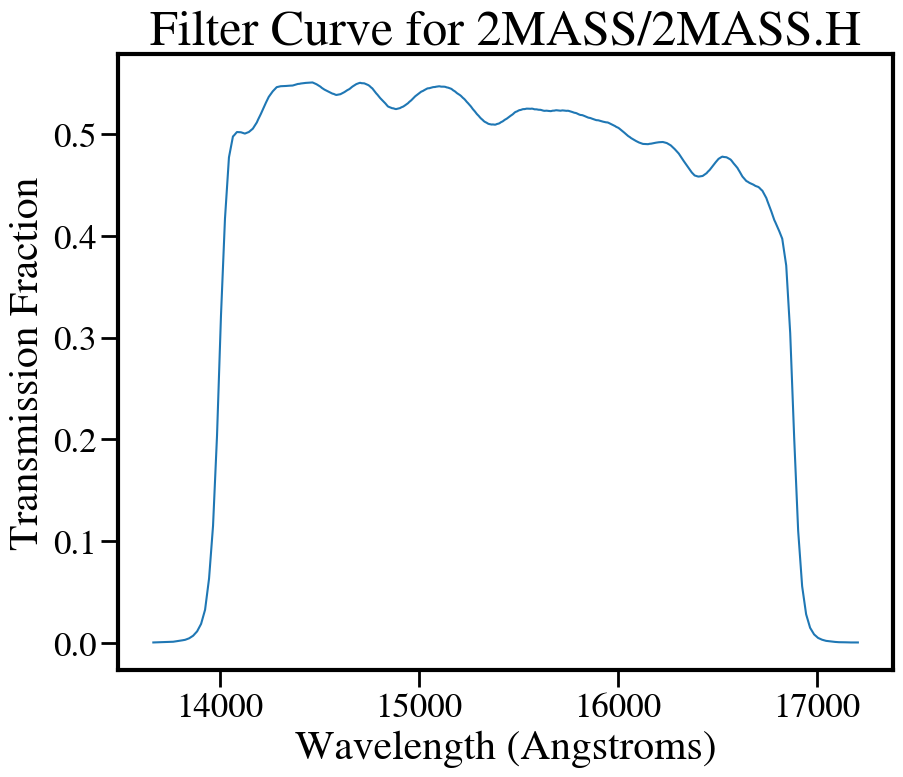

In [13]:
import matplotlib.pyplot as plt
plt.plot(data['Wavelength'], data['Transmission'])
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Transmission Fraction')
plt.title('Filter Curve for 2MASS/2MASS.H')
plt.show()

In [20]:
from astroquery.svo_fps import SvoFps
from astropy import units as u

from astroquery.svo_fps import SvoFps
from astropy import units as u

def get_svo_filters(facility, instrument, filters=None, wave_unit='micron'):
    """
    Retrieve SVO filter transmission curves as a dictionary.

    Parameters
    ----------
    facility : str
        e.g. 'JWST'
    instrument : str
        e.g. 'NIRCam'
    filters : list or None
        List of filter names (e.g. ['F200W','F356W']).
        If None → fetch all available filters.
    wave_unit : str
        Output wavelength unit ('micron', 'angstrom', etc.)

    Returns
    -------
    dict
        {
            'F200W': {
                'Wavelength': array,
                'Transmission': array
            },
            ...
        }
    """

    # --- Get full filter list if not provided ---
    if filters is None:
        filt_table = SvoFps.get_filter_list(
            facility=facility,
            instrument=instrument
        )
        filters = [f.split('.')[-1] for f in filt_table['filterID']]

    out = {}

    for f in filters:
        filter_id = f"{facility}/{instrument}.{f}"

        try:
            data = SvoFps.get_transmission_data(filter_id)

            # Convert wavelength
            wl = data['Wavelength']
            wl = wl.to(wave_unit).value

            trans = data['Transmission']

            out[f] = {
                'Wavelength': wl,
                'Transmission': trans
            }

        except Exception as e:
            print(f"Skipping {f}: {e}")

    return out

In [30]:
from astroquery.svo_fps import SvoFps
from astropy import units as u

def get_svo_filters(facility, instrument, filters=None, wave_unit='micron'):
    """
    Retrieve SVO filter transmission curves as a dictionary.
    """

    def fetch_single_filter(f):
        """Helper to fetch one filter"""
        filter_id = f"{facility}/{instrument}.{f}"

        data = SvoFps.get_transmission_data(filter_id)

        # Attach units explicitly (SVO gives raw numbers)
        wl = (data['Wavelength']).to(wave_unit).value
        trans = data['Transmission']

        return {
            'Wavelength': wl,
            'Transmission': trans
        }

    # --- Case 1: No filters → fetch all ---
    if filters is None:
        filt_table = SvoFps.get_filter_list(
            facility=facility,
            instrument=instrument
        )
        filters = [f.split('.')[-1] for f in filt_table['filterID']]

    # --- Case 2: Single filter (string) ---
    if isinstance(filters, str):
        try:
            return {filters: fetch_single_filter(filters)}
        except Exception as e:
            print(f"Skipping {filters}: {e}")
            return {}

    # --- Case 3: Iterable of filters ---
    out = {}

    for f in filters:
        try:
            out[f] = fetch_single_filter(f)
        except Exception as e:
            print(f"Skipping {f}: {e}")

    return out

In [31]:
filters = get_svo_filters(facility='JWST', instrument='NIRCam', filters='F200W')

In [24]:
filters['F070W']['wavelength']

array([0.60315, 0.60415, 0.60515, 0.60615, 0.60715, 0.60815, 0.60915,
       0.61015, 0.61115, 0.61215, 0.61315, 0.61415, 0.61515, 0.61615,
       0.61715, 0.61815, 0.61915, 0.62015, 0.62115, 0.62215, 0.62315,
       0.62415, 0.62515, 0.62615, 0.62715, 0.62815, 0.62915, 0.63015,
       0.63115, 0.63215, 0.63315, 0.63415, 0.63515, 0.63615, 0.63715,
       0.63815, 0.63915, 0.64015, 0.64115, 0.64215, 0.64315, 0.64415,
       0.64515, 0.64615, 0.64715, 0.64815, 0.64915, 0.65015, 0.65115,
       0.65215, 0.65315, 0.65415, 0.65515, 0.65615, 0.65715, 0.65815,
       0.65915, 0.66015, 0.66115, 0.66215, 0.66315, 0.66415, 0.66515,
       0.66615, 0.66715, 0.66815, 0.66915, 0.67015, 0.67115, 0.67215,
       0.67315, 0.67415, 0.67515, 0.67615, 0.67715, 0.67815, 0.67915,
       0.68015, 0.68115, 0.68215, 0.68315, 0.68415, 0.68515, 0.68615,
       0.68715, 0.68815, 0.68915, 0.69015, 0.69115, 0.69215, 0.69315,
       0.69415, 0.69515, 0.69615, 0.69715, 0.69815, 0.69915, 0.70015,
       0.70115, 0.70

In [32]:
filters

{'F200W': {'Wavelength': array([1.6904, 1.6914, 1.6924, 1.6934, 1.6944, 1.6954, 1.6964, 1.6974,
         1.6984, 1.6994, 1.7004, 1.7014, 1.7024, 1.7034, 1.7044, 1.7054,
         1.7064, 1.7074, 1.7084, 1.7094, 1.7104, 1.7114, 1.7124, 1.7134,
         1.7144, 1.7154, 1.7164, 1.7174, 1.7184, 1.7194, 1.7204, 1.7214,
         1.7224, 1.7234, 1.7244, 1.7254, 1.7264, 1.7274, 1.7284, 1.7294,
         1.7304, 1.7314, 1.7324, 1.7334, 1.7344, 1.7354, 1.7364, 1.7374,
         1.7384, 1.7394, 1.7404, 1.7414, 1.7424, 1.7434, 1.7444, 1.7454,
         1.7464, 1.7474, 1.7484, 1.7494, 1.7504, 1.7514, 1.7524, 1.7534,
         1.7544, 1.7554, 1.7564, 1.7574, 1.7584, 1.7594, 1.7604, 1.7614,
         1.7624, 1.7634, 1.7644, 1.7654, 1.7664, 1.7674, 1.7684, 1.7694,
         1.7704, 1.7714, 1.7724, 1.7734, 1.7744, 1.7754, 1.7764, 1.7774,
         1.7784, 1.7794, 1.7804, 1.7814, 1.7824, 1.7834, 1.7844, 1.7854,
         1.7864, 1.7874, 1.7884, 1.7894, 1.7904, 1.7914, 1.7924, 1.7934,
         1.7944, 1.7954, 1.7

In [2]:
from simbanator.sed.flux_extraction import get_svo_filters
profiles = get_svo_filters(
    facility=['JWST', 'HST'],
    instrument=['NIRCam', 'WFC3'],
    filters=None
)

In [3]:
profiles

{'JWST': {'NIRCam': {'F070W': {'Wavelength': array([0.60315002, 0.60415002, 0.60515002, 0.60615002, 0.60715002,
           0.60815002, 0.60915002, 0.61015002, 0.61115002, 0.61215002,
           0.61315002, 0.61415002, 0.61515002, 0.61615002, 0.61715002,
           0.61815002, 0.61915002, 0.62015002, 0.62115002, 0.62215002,
           0.62315002, 0.62415002, 0.62515002, 0.62615002, 0.62715002,
           0.62815002, 0.62915002, 0.63015002, 0.63115002, 0.63215002,
           0.63315002, 0.63415002, 0.63515002, 0.63615002, 0.63715002,
           0.63815002, 0.63915002, 0.64015002, 0.64115002, 0.64215002,
           0.64315002, 0.64415002, 0.64515002, 0.64615002, 0.64715002,
           0.64815002, 0.64915002, 0.65015002, 0.65115002, 0.65215002,
           0.65315002, 0.65415002, 0.65515002, 0.65615002, 0.65715002,
           0.65815002, 0.65915002, 0.66015002, 0.66115002, 0.66215002,
           0.66315002, 0.66415002, 0.66515002, 0.66615002, 0.66715002,
           0.66815002, 0.66915002, 0